In [1]:
from google.colab import files

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import string
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Upload file
my_data = files.upload()

Saving Data_fake_or_real_news.csv to Data_fake_or_real_news.csv


In [5]:
data = list(my_data.keys())[0]

In [6]:
data

'Data_fake_or_real_news.csv'

In [8]:
# Read CSV
df = pd.read_csv(data)

# Preview
df.head(10)

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
5,6903,"Tehran, USA","\nI’m not an immigrant, but my grandparents ...",FAKE
6,7341,Girl Horrified At What She Watches Boyfriend D...,"Share This Baylee Luciani (left), Screenshot o...",FAKE
7,95,‘Britain’s Schindler’ Dies at 106,A Czech stockbroker who saved more than 650 Je...,REAL
8,4869,Fact check: Trump and Clinton at the 'commande...,Hillary Clinton and Donald Trump made some ina...,REAL
9,2909,Iran reportedly makes new push for uranium con...,Iranian negotiators reportedly have made a las...,REAL


In [9]:
print(df.shape)

(6335, 4)


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6335 non-null   int64 
 1   title   6335 non-null   object
 2   text    6294 non-null   object
 3   label   6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB
None


In [11]:
print(df.isnull().sum())

id        0
title     0
text     41
label     0
dtype: int64


In [12]:
# Columns
print("Columns:", df.columns)

Columns: Index(['id', 'title', 'text', 'label'], dtype='object')


#Label distribution

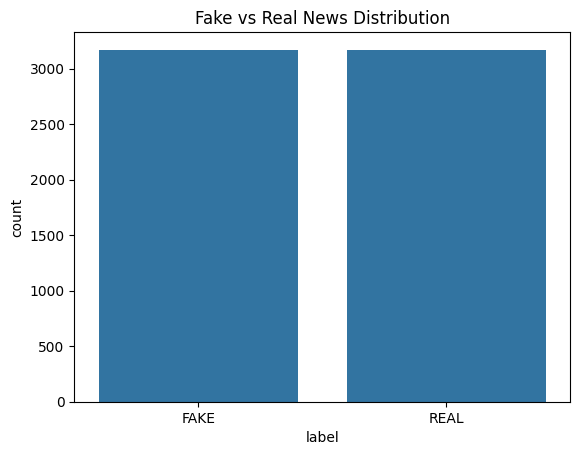

In [13]:
sns.countplot(x='label', data=df)
plt.title("Fake vs Real News Distribution")
plt.show()

#Text Length Analysis

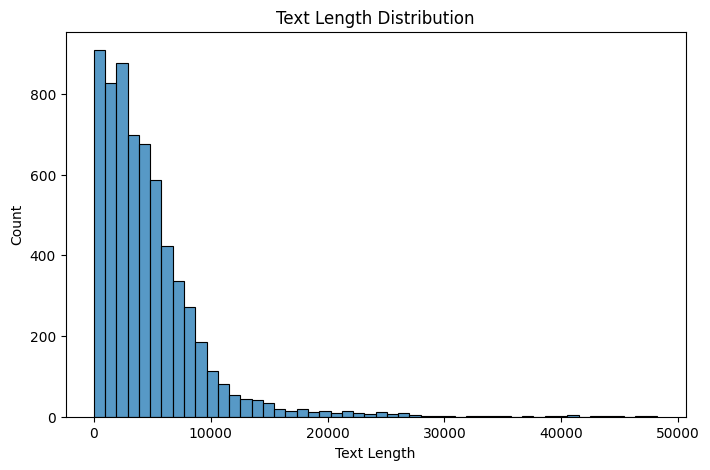

In [14]:
# Clean text column first
df['text'] = df['text'].fillna('').astype(str)

# Create length feature
df['text_length'] = df['text'].apply(len)

# Plot
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.show()

In [15]:
print("Min length:", df['text_length'].min())
print("Max length:", df['text_length'].max())
print("Average length:", df['text_length'].mean())

Min length: 0
Max length: 48229
Average length: 4635.813101815312


#Text Preprocessing

In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

#Encode Labels

In [17]:
df['label'] = df['label'].map({'FAKE': 0, 'REAL': 1})

In [18]:
fake_texts = df[df['label'] == 0]['text']
real_texts = df[df['label'] == 1]['text']

In [19]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_words(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:
fake_words = []
for text in fake_texts:
    fake_words.extend(get_words(text))

real_words = []
for text in real_texts:
    real_words.extend(get_words(text))

In [21]:
top_fake_words = Counter(fake_words).most_common(20)
top_real_words = Counter(real_words).most_common(20)

print("🔥 Top Fake News Words:")
for word, count in top_fake_words:
    print(word, "->", count)

print("\n✅ Top Real News Words:")
for word, count in top_real_words:
    print(word, "->", count)

🔥 Top Fake News Words:
trump -> 5706
clinton -> 5670
people -> 4944
one -> 4708
would -> 4633
hillary -> 4103
said -> 3930
new -> 3426
also -> 3101
like -> 3063
election -> 2981
even -> 2775
time -> 2747
world -> 2714
state -> 2621
government -> 2497
many -> 2462
could -> 2413
president -> 2397
war -> 2326

✅ Top Real News Words:
said -> 17187
trump -> 12694
clinton -> 8769
would -> 7779
one -> 6314
people -> 6154
new -> 5772
president -> 5684
state -> 5576
campaign -> 5374
also -> 5028
republican -> 4857
obama -> 4663
states -> 4325
could -> 4041
like -> 3831
time -> 3650
sanders -> 3592
party -> 3560
even -> 3529


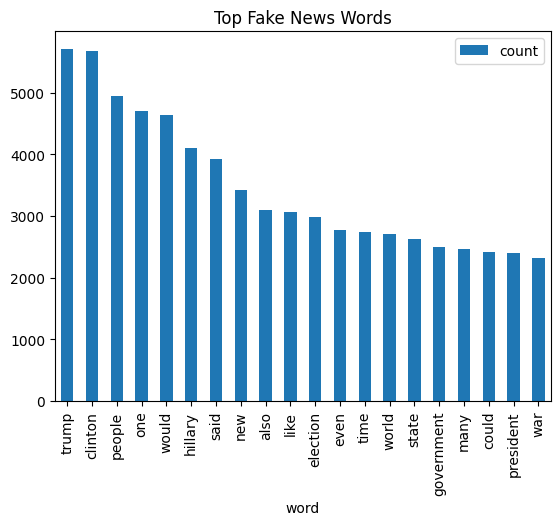

In [22]:
fake_df = pd.DataFrame(top_fake_words, columns=["word", "count"])
real_df = pd.DataFrame(top_real_words, columns=["word", "count"])

fake_df.plot(kind='bar', x='word', y='count', title='Top Fake News Words')
plt.show()

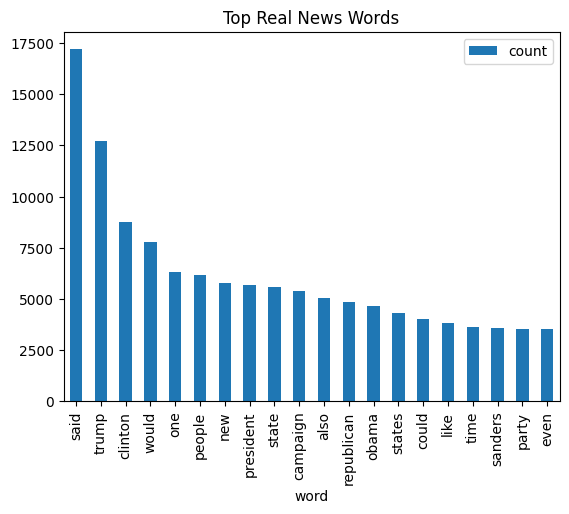

In [23]:
real_df.plot(kind='bar', x='word', y='count', title='Top Real News Words')
plt.show()

#Train-Test Split

In [24]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
X_train

,clean_text
1142,donald trump received a key endorsement for hi...
2654,nina november pm polish government and com...
5395,time investigating hillary is an attack on all...
1170,takis magazine october this election is goin...
4371,pakistan pakistans cricketer turned politician...
...,...
3772,what happened was less a debate among contende...
5191,clinton fbigate and the true depth of the obam...
5226,fearing election day trouble some us schools c...
5390,president obama’s appearance at a town hall me...


In [26]:
y_train

,label
1142,1
2654,0
5395,0
1170,0
4371,0
...,...
3772,1
5191,0
5226,0
5390,1


#Vectorization

##Bag of Words

In [27]:
bow = CountVectorizer(stop_words='english', max_df=0.7)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

##TF-IDF

In [28]:
df['text_length'] = df['text'].apply(len)

In [29]:
df['text_length']

,text_length
0,7518
1,2646
2,2543
3,2660
4,1840
...,...
6330,4076
6331,14323
6332,11974
6333,6991


In [30]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    ngram_range=(1,2)   # 🔥 unigram + bigram
)

In [31]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['unique_word_count'] = df['clean_text'].apply(lambda x: len(set(x.split())))
df['stopword_count'] = df['clean_text'].apply(lambda x: len([w for w in x.split() if w in stopwords.words('english')]))

In [34]:
from scipy.sparse import hstack

extra_features = df[['text_length', 'word_count']]

X_train_extra = extra_features.iloc[X_train.index]
X_test_extra = extra_features.iloc[X_test.index]

X_train_combined = hstack([X_train_tfidf, X_train_extra])
X_test_combined = hstack([X_test_tfidf, X_test_extra])

In [35]:
X_train_extra

,text_length,word_count
1142,161,23
2654,668,109
5395,2160,365
1170,3067,531
4371,2656,408
...,...,...
3772,8666,1496
5191,5078,861
5226,2076,327
5390,7132,1171


In [36]:
X_train_combined

<COOrdinate sparse matrix of dtype 'float64'
	with 3112642 stored elements and shape (5068, 1369817)>

#Scalling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)  # important for sparse data
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

#Train Models

##Logistic Regression

In [79]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [39]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
lr_cv = LogisticRegression()

cv_scores = cross_val_score(lr_cv, X_train_tfidf, y_train, cv=5, scoring='accuracy')

print("Logistic Regression CV Accuracy:")
print("Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Logistic Regression CV Accuracy:
Scores: [0.89053254 0.88856016 0.90138067 0.91905232 0.89141165]
Mean Accuracy: 0.8981874682383454


# LR Model on Scaled Data




In [40]:
model = LogisticRegression(solver='saga', max_iter=1000)

In [41]:
model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, solver='saga')

In [42]:
y_pred_model = model.predict(X_test_scaled)

##Naive Bayes

In [86]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

# Naive Bayes on Scaled Data

In [80]:
nb_model = MultinomialNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb_model = nb_model.predict(X_test_scaled)

##Random Forest

In [87]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)

# Random Forest on Scaled Data

In [81]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf_model = rf_model.predict(X_test_scaled)

#SVM

In [88]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

In [46]:
svm_cv = LinearSVC()

cv_scores_svm = cross_val_score(svm_cv, X_train_tfidf, y_train, cv=5, scoring='accuracy')

print("SVM CV Accuracy:")
print("Scores:", cv_scores_svm)
print("Mean Accuracy:", cv_scores_svm.mean())

SVM CV Accuracy:
Scores: [0.91913215 0.91518738 0.92307692 0.93583416 0.91806515]
Mean Accuracy: 0.9222591517374721


In [48]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### SVM Model on Scaled Data

In [82]:
svm_model = LinearSVC()
svm_model.fit(X_train_scaled, y_train)
y_pred_svm_model= svm_model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#Xgboost

In [47]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00


In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

# XGBoosT Model on Scaled Data

In [73]:
from xgboost import XGBClassifier

modelx = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

modelx.fit(X_train_scaled, y_train)

y_pred_modelx = modelx.predict(X_test_scaled)

#Evaluation Function

In [50]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

--- Logistic Regression ---
Accuracy: 0.920284135753749

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       628
           1       0.91      0.93      0.92       639

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267



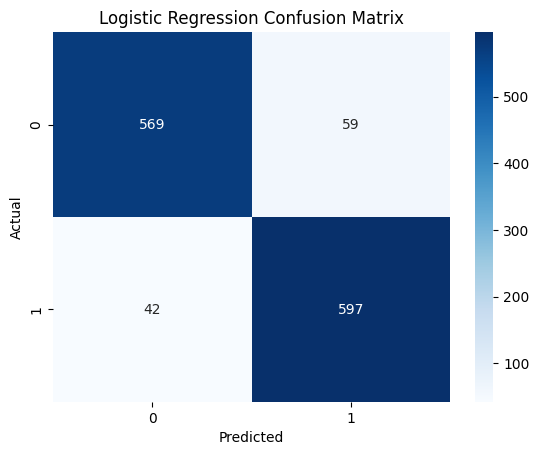

--- Naive Bayes ---
Accuracy: 0.8397790055248618

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.68      0.81       628
           1       0.76      1.00      0.86       639

    accuracy                           0.84      1267
   macro avg       0.88      0.84      0.84      1267
weighted avg       0.88      0.84      0.84      1267



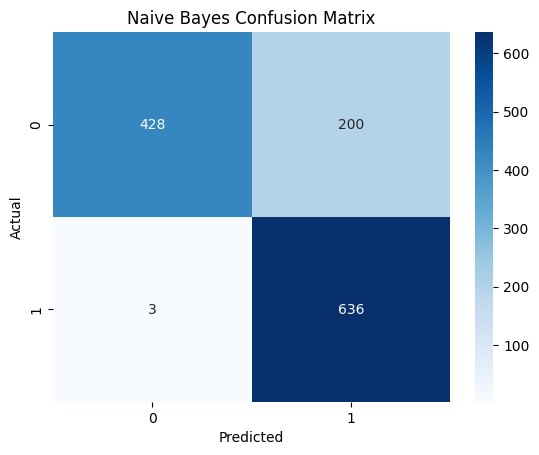

--- Random Forest ---
Accuracy: 0.8966061562746646

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       628
           1       0.90      0.90      0.90       639

    accuracy                           0.90      1267
   macro avg       0.90      0.90      0.90      1267
weighted avg       0.90      0.90      0.90      1267



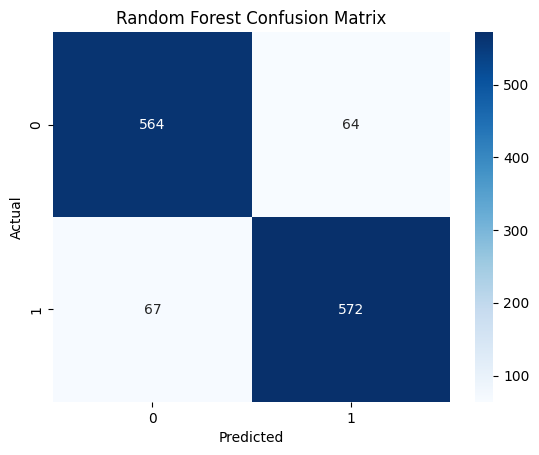

--- SVM ---
Accuracy: 0.9368587213891081

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94       628
           1       0.93      0.95      0.94       639

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267



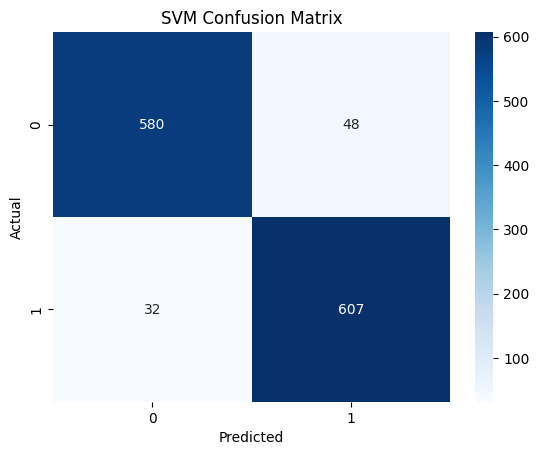

--- XGBoost ---
Accuracy: 0.9265982636148382

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       628
           1       0.93      0.92      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



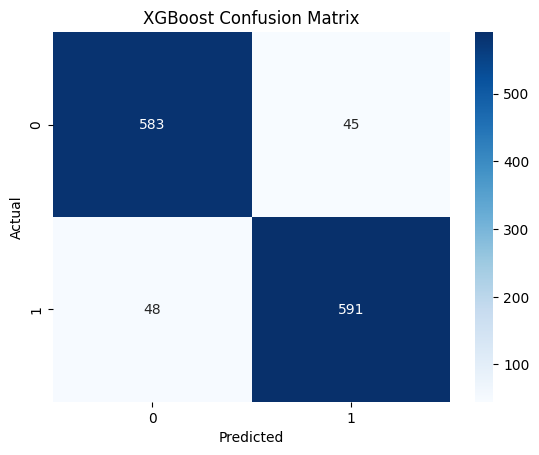

In [89]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_svm, "SVM")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


afer scalling

--- Logistic Regression ---
Accuracy: 0.9352801894238358

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       628
           1       0.93      0.95      0.94       639

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267



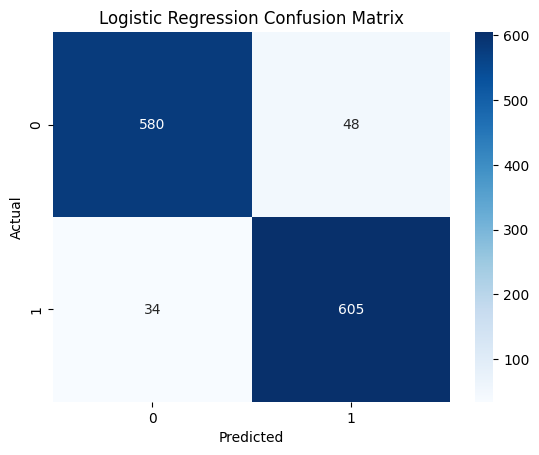

--- Naive Bayes ---
Accuracy: 0.8784530386740331

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.79      0.87       628
           1       0.82      0.96      0.89       639

    accuracy                           0.88      1267
   macro avg       0.89      0.88      0.88      1267
weighted avg       0.89      0.88      0.88      1267



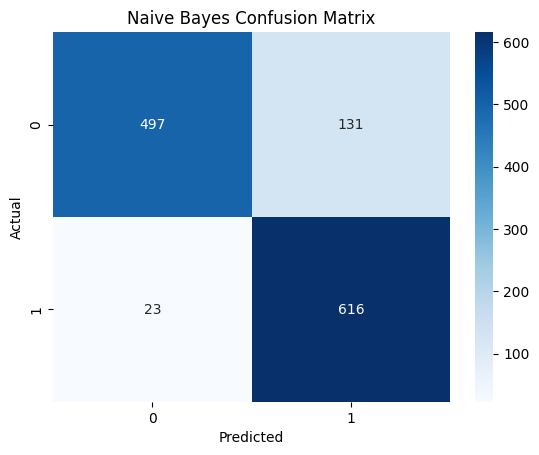

--- Random Forest ---
Accuracy: 0.8879242304656669

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89       628
           1       0.89      0.89      0.89       639

    accuracy                           0.89      1267
   macro avg       0.89      0.89      0.89      1267
weighted avg       0.89      0.89      0.89      1267



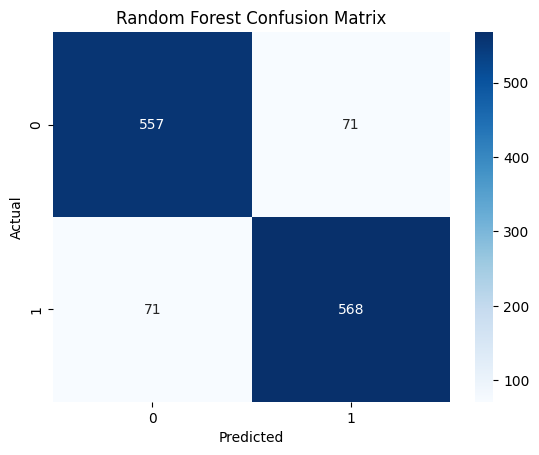

--- SVM ---
Accuracy: 0.8334648776637726

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.93      0.85       628
           1       0.92      0.73      0.82       639

    accuracy                           0.83      1267
   macro avg       0.85      0.83      0.83      1267
weighted avg       0.85      0.83      0.83      1267



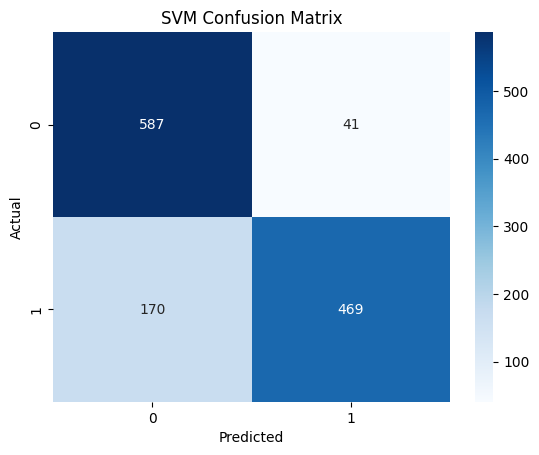

--- XGBoost ---
Accuracy: 0.9163378058405682

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92       628
           1       0.92      0.91      0.92       639

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267



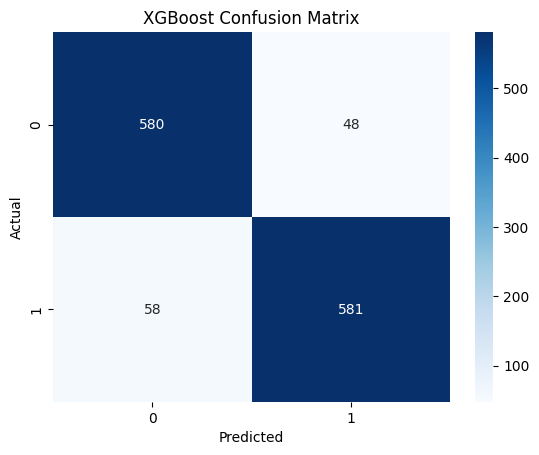

In [83]:
evaluate_model(y_test, y_pred_model, "Logistic Regression")
evaluate_model(y_test, y_pred_nb_model, "Naive Bayes")
evaluate_model(y_test, y_pred_rf_model, "Random Forest")
evaluate_model(y_test, y_pred_svm_model, "SVM")
evaluate_model(y_test, y_pred_modelx, "XGBoost")

#Model Comparison

In [90]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Xgboost": accuracy_score(y_test, y_pred_svm),

}

pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).sort_values(by='Accuracy', ascending=False)

,Accuracy
Xgboost,0.936859
SVM,0.936859
Logistic Regression,0.920284
Random Forest,0.896606
Naive Bayes,0.839779


#RESULTS AFTER SCALLING AND FEATURE ENGINEERING

In [85]:
results_scaled = {
    "Logistic Regression": accuracy_score(y_test, y_pred_model),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb_model),
    "Random Forest": accuracy_score(y_test, y_pred_rf_model),
    "SVM": accuracy_score(y_test, y_pred_svm_model),
    "Xgboost": accuracy_score(y_test, y_pred_modelx),

}


pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).sort_values(by='Accuracy', ascending=False)

,Accuracy
SVM,0.940805
Logistic Regression,0.933702
Naive Bayes,0.930545
XGBoost,0.926598
Random Forest,0.901342


#Test with Custom Input

In [52]:
def predict_news(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    prediction = lr.predict(vector)

    return "REAL NEWS" if prediction[0] == 1 else "FAKE NEWS"

# Example
print(predict_news("Breaking: Government announces new policy today"))

FAKE NEWS


#Hyperparameter Tuning (GridSearchCV)

🔥 A) Logistic Regression Tuning

In [98]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score: 0.9179169806324488


--- Tuned Logistic Regression ---
Accuracy: 0.9337016574585635

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       628
           1       0.92      0.95      0.94       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



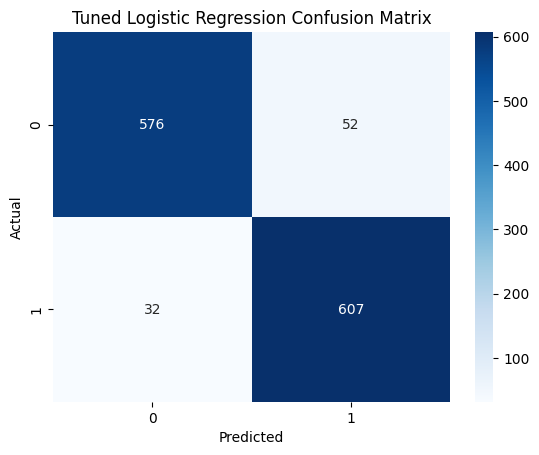

In [99]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test_tfidf)

evaluate_model(y_test, y_pred_lr, "Tuned Logistic Regression")

#⚡ B) SVM Tuning

In [100]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge']
}

grid_svm = GridSearchCV(
    LinearSVC(),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

Best SVM Params: {'C': 1, 'loss': 'hinge'}
Best SVM Score: 0.9264031106464093


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [101]:
best_model = grid_svm.best_estimator_  # example

y_pred = best_model.predict(X_test_tfidf)

--- Tuned SVM ---
Accuracy: 0.9408050513022889

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       628
           1       0.93      0.95      0.94       639

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267



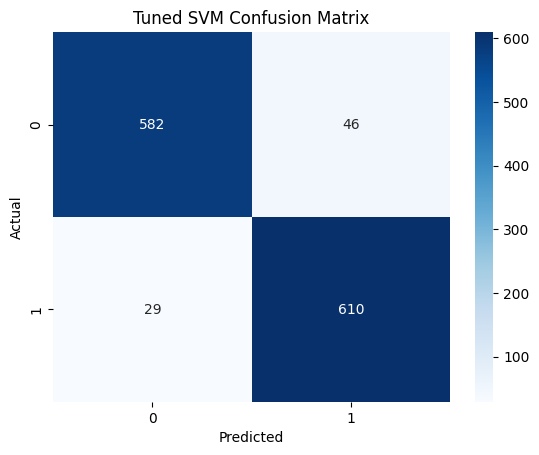

In [102]:
evaluate_model(y_test, y_pred, "Tuned SVM")

#🌲 C) Random Forest Tuning

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_tfidf, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test_tfidf)

evaluate_model(y_test, y_pred_rf, "Tuned Random Forest")

#🚀 D) XGBoost Tuning

In [63]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train_tfidf, y_train)

print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB Score:", grid_xgb.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:47:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best XGB Score: 0.9096319963378304


--- Tuned XGBoost ---
Accuracy: 0.9265982636148382

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       628
           1       0.93      0.92      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



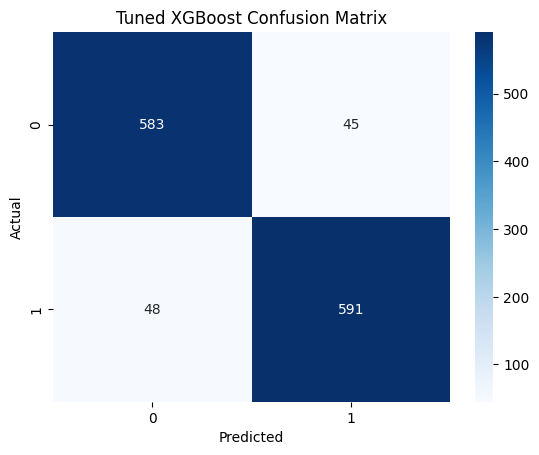

In [65]:
# ✅ Evaluation
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_tfidf)

evaluate_model(y_test, y_pred_xgb, "Tuned XGBoost")

# **🎲** E) Naive Bayes Tuning

In [61]:
from sklearn.model_selection import GridSearchCV
param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}
grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train_tfidf, y_train)

print("Best Alpha:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Alpha: {'alpha': 0.01}
Best CV Score: 0.9191041120268851


--- Tuned Naive Bayes ---
Accuracy: 0.930544593528019

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       628
           1       0.90      0.97      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



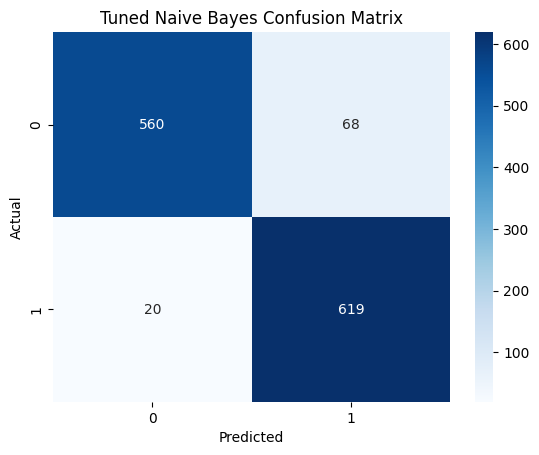

In [62]:
# Evaluation
best_nb = grid_nb.best_estimator_
y_pred_nb = best_nb.predict(X_test_tfidf)

evaluate_model(y_test, y_pred_nb, "Tuned Naive Bayes")

#Store all tuned models

In [66]:
best_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Naive Bayes": grid_nb.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "SVM": grid_svm.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}

#Predict + Evaluate All Models


🔹 Logistic Regression
--- Logistic Regression ---
Accuracy: 0.9337016574585635

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       628
           1       0.92      0.95      0.94       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



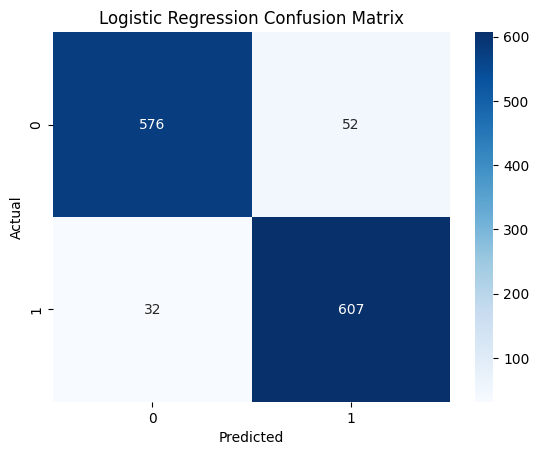


🔹 Naive Bayes
--- Naive Bayes ---
Accuracy: 0.930544593528019

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       628
           1       0.90      0.97      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



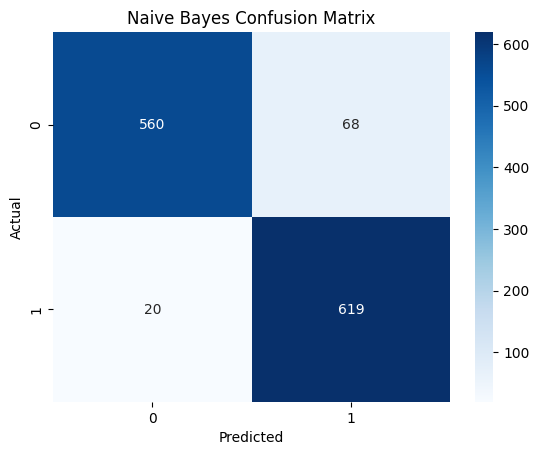


🔹 Random Forest
--- Random Forest ---
Accuracy: 0.9013417521704814

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       628
           1       0.90      0.91      0.90       639

    accuracy                           0.90      1267
   macro avg       0.90      0.90      0.90      1267
weighted avg       0.90      0.90      0.90      1267



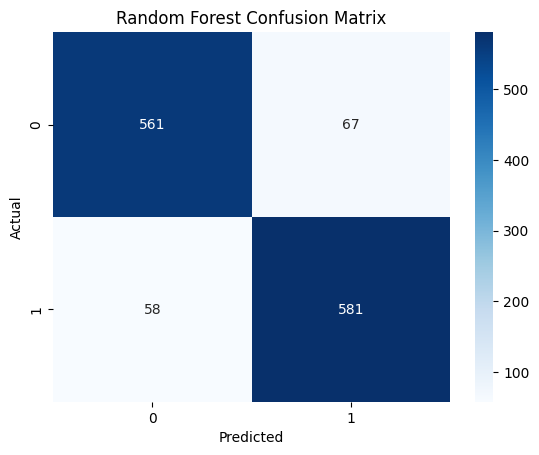


🔹 SVM
--- SVM ---
Accuracy: 0.9408050513022889

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       628
           1       0.93      0.95      0.94       639

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267



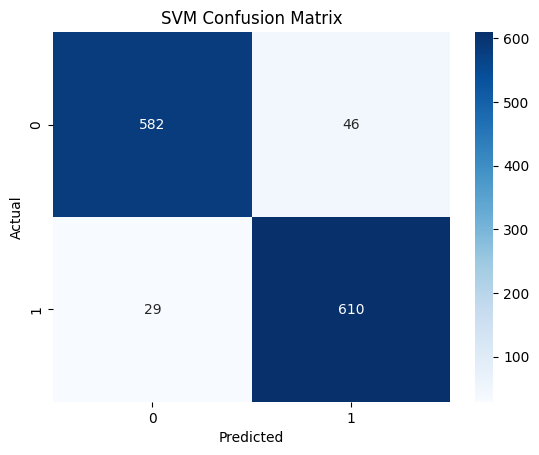


🔹 XGBoost
--- XGBoost ---
Accuracy: 0.9265982636148382

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       628
           1       0.93      0.92      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



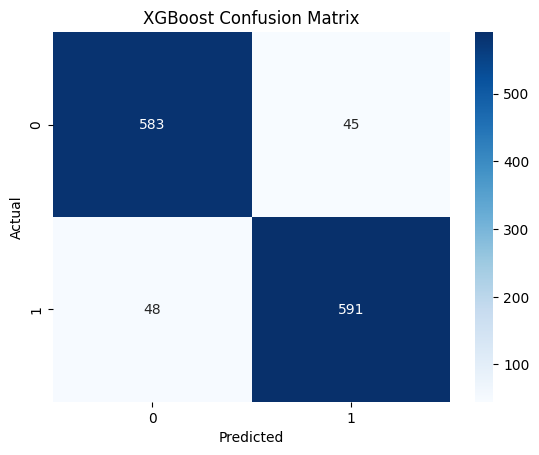

In [67]:
results = {}

for name, model in best_models.items():

    y_pred = model.predict(X_test_tfidf)

    print(f"\n🔹 {name}")
    evaluate_model(y_test, y_pred, name)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

#Show Comparison Table

In [68]:
import pandas as pd

df_results = pd.DataFrame.from_dict(
    results, orient='index', columns=['Accuracy']
).sort_values(by='Accuracy', ascending=False)

print(df_results)

                     Accuracy
SVM                  0.940805
Logistic Regression  0.933702
Naive Bayes          0.930545
XGBoost              0.926598
Random Forest        0.901342


#Visual Comparison

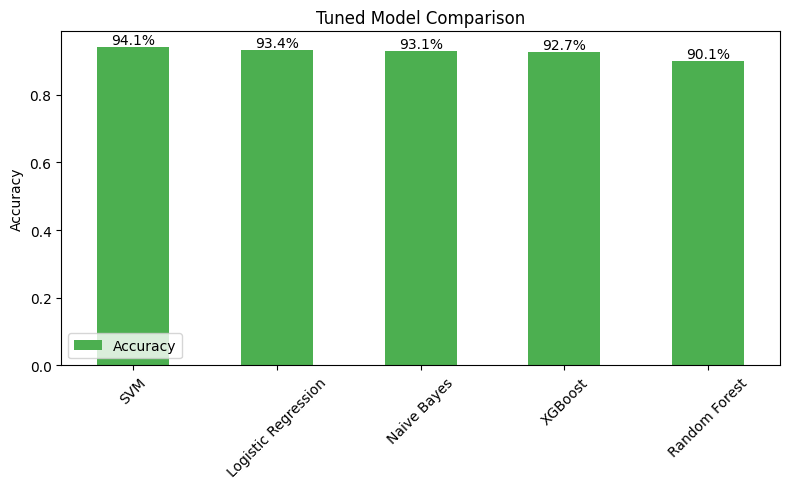

In [70]:
import matplotlib.pyplot as plt

ax = df_results.plot(
    kind='bar',
    figsize=(8,5),
    color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']  # customize colors
)

plt.title("Tuned Model Comparison")
plt.ylabel("Accuracy")

# Add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height*100:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=10,
                color='black')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#ROC-AUC for ALL tuned models

In [71]:
from sklearn.metrics import roc_auc_score

auc_results = {}

for name, model in best_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    auc_score = roc_auc_score(y_test, y_score)
    auc_results[name] = auc_score

df_auc = pd.DataFrame.from_dict(
    auc_results, orient='index', columns=['ROC-AUC']
).sort_values(by='ROC-AUC', ascending=False)

print(df_auc)

                      ROC-AUC
SVM                  0.987426
Logistic Regression  0.985168
Naive Bayes          0.983224
XGBoost              0.980468
Random Forest        0.965940


# Roc Curves

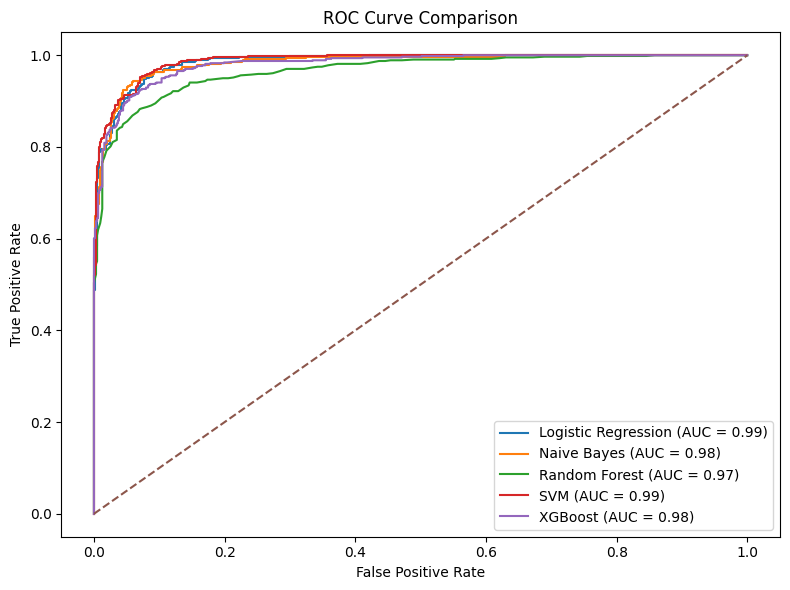

In [72]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in best_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()